In [3]:
%load_ext autoreload
%autoreload 2

import os
os.chdir("C:/Users/Administrator/PythonProjects/abfluss_queich")

## RADOLAN HOURLY

#### process_radolan.py

In [23]:
from tqdm import tqdm
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd

import wradlib as wrl
import xarray as xr
import rioxarray

import matplotlib.pyplot as plt

from configs import settings
from utils.logger import logger

In [12]:
def read_radolan_data(
    file_path: str | Path
    ) -> tuple[np.ndarray, dict]:
    
    file_path = str(file_path)
    
    try:
        data, attrs = wrl.io.read_radolan_composite(file_path)
        
        data = np.array(data).astype(float)
        data = np.where(data == -9999, np.nan, data)
    
    except Exception:
        logger.exception("Failed to open RADOLAN BIN file: %s", file_path)
        raise
        
    return data, attrs


def get_observation_date(href: str) -> pd.Timestamp:
    
    _, _, date, _ = href.split("-", maxsplit=3)
    
    return pd.to_datetime(date, format="%y%m%d%H%M")


def extract_radolan_timestamp(
    file_path: str | Path
    ) -> pd.Timestamp:
    
    stem = Path(file_path).stem
    
    _, _, timestring, _ = stem.split("-", maxsplit=3)
    
    observation_time = pd.to_datetime(timestring, format="%y%m%d%H%M")
    
    return observation_time


def extract_radolan_coords(
    attrs: dict
    ) -> tuple[np.ndarray, np.ndarray]:
    
    grid = wrl.georef.get_radolan_grid(
        attrs["nrow"],
        attrs["ncol"]
    )
    
    x2d = np.array(grid)[:, :, 0]
    y2d = np.array(grid)[:, :, 1]
    
    return x2d, y2d


def radolan_to_xarray(
    file_path: str | Path
    ) -> xr.DataArray:
    
    data, attrs = read_radolan_data(file_path=file_path)
    
    observation_time = extract_radolan_timestamp(file_path=file_path)
    
    x2d, y2d = extract_radolan_coords(attrs=attrs)
    
    
    data_xr = xr.DataArray(
        data[np.newaxis, :, :],
        dims=("time", "y", "x"),
        coords={
            "time": [observation_time],
            "x": x2d[0, :],
            "y": y2d[:, 0],
            },
        name="precip"
        )
    
    data_xr = data_xr.rio.set_spatial_dims(x_dim="x", y_dim="y")
    data_xr = data_xr.rio.write_crs(wrl.georef.projection.create_crs("dwd-radolan"))
        

    return data_xr


def clip_to_catchment(
    dataset: xr.DataArray,
    catchment: gpd.GeoDataFrame,
    ) -> xr.DataArray:
    
    precip = dataset
    
    # Check CRS
    catchment = catchment.to_crs(dataset.rio.crs)
    
    
     # --- Crop bounding box of catchment ---
    minx, miny, maxx, maxy = catchment.total_bounds

    precip_crop = precip.rio.clip_box(
        minx=minx,
        miny=miny,
        maxx=maxx,
        maxy=maxy,
    )
    
    # # --- Optional geometry clip ---
    # precip_crop = precip.rio.clip(
    #     catchment.geometry,
    #     # catchment.crs,
    #     drop=False,
    # )
    
    return precip_crop  


def extract_precip_timeseries(
    file_path: str | Path,
    catchment: gpd.GeoDataFrame,
    ) -> dict:
    
    data_xr = radolan_to_xarray(file_path=file_path)
    
    precip_clipped = clip_to_catchment(
        dataset=data_xr,
        catchment=catchment,
        )

    observed_time = pd.to_datetime(precip_clipped.time.item())
    precip_mean = float(precip_clipped.mean(skipna=True)) 

    row = {
        "timestamp": observed_time,
        "precip_mean": precip_mean
        }
    
    return row


def resample_precip(df: pd.DataFrame) -> pd.DataFrame:
    
    df_10min = df.copy()

    df_10min.index = df_10min.index - pd.Timedelta(minutes=10)

    df_1min = (
        df_10min / 10
        ).reindex(
            pd.date_range(
                df_10min.index[0],
                df_10min.index[-1] + pd.Timedelta(minutes=9),
                freq="1min",
            ),
            method="ffill",
        )

    df_15min = df_1min.resample("15min").sum()
    
    return df_15min


def build_precip_timeseries(
    input_dir: str | Path,
    catchment_path: str | Path,
    start: pd.Timestamp | None = None
    ) -> pd.DataFrame:
    
    input_dir = Path(input_dir)
    
    file_paths = sorted(input_dir.rglob("*.gz"))
    
    if start is not None:
        file_paths = [
            p for p in file_paths
            if extract_radolan_timestamp(p) > start
        ]
    
    catchment = gpd.read_file(catchment_path)
    
    
    # --- Extract dataset ---
    dfs = []
    
    for path in tqdm(file_paths, desc="Processing files"):
        try:
            dict_precip = extract_precip_timeseries(
                file_path=path,
                catchment=catchment
            )
            
            dfs.append(dict_precip)
            
        except Exception:
            logger.exception("Failed to process RADOLAN BIN file %s:", path)
            continue
    
    
    # --- Process dataframe ---
    df = pd.DataFrame.from_records(dfs)
    
    df = df.set_index("timestamp")
    df = df.sort_index()
    df = df[~df.index.duplicated(keep="last")]
    
    df = resample_precip(df)
                
    return df

In [46]:
radolan_settings = settings.ingestion.radolan_hourly

path = "C:/Users/Administrator/PythonProjects/abfluss_queich/data/test/radolan/compressed/raa01-rw_10000-2605302250-dwd---bin.gz"

latest_ts = pd.to_datetime("2026-06-01 23:45:00")

df = build_precip_timeseries(
    input_dir=radolan_settings.compressed_dir,
    catchment_path=settings.ingestion.catchment.catchment_path,
    start=latest_ts
)

Processing files: 100%|██████████| 75/75 [00:19<00:00,  3.86it/s]


<Axes: xlabel='timestamp'>

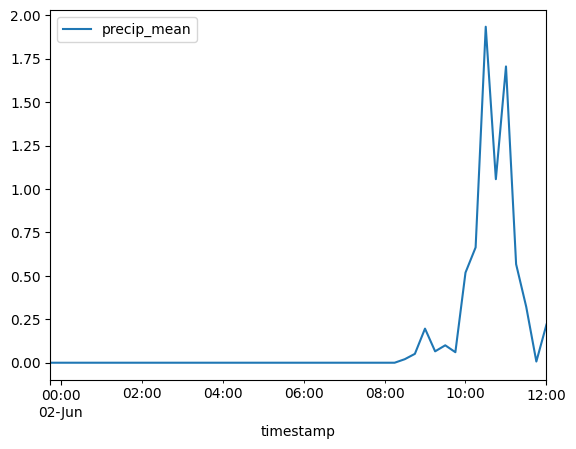

In [49]:
df.plot()